# SVNIT Department of Artificial Intelligence
## Subject: Machine Learning (AI301)
### Assignment 4: California Housing Regression, Pipelines, and Model Fine-Tuning

---

**Student Name:** Jeetu Mehra  
**Roll Number:** U24AI032  
**Semester:** B.Tech Artificial Intelligence  
**Institution:** Sardar Vallabhbhai National Institute of Technology (SVNIT), Surat  

---

**Aim:**  
To implement a complete end-to-end Machine Learning regression pipeline on the California Housing (1990 census) dataset, including stratified sampling, robust feature preprocessing via `ColumnTransformer`, cross-validation of multiple regression algorithms, hyperparameter tuning with `GridSearchCV`, closed-form Normal Equation implementation from scratch in NumPy, and diagnostic visual analytics.

**Objectives:**
1. **Question 1:** Create an `income_cat` column by binning `median_income` with edges `[0, 1.5, 3.0, 4.5, 6.0, np.inf]` labeled `1–5`. Perform stratified train-test splitting using `StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)` and report income category counts.
2. **Question 2:** Construct a `ColumnTransformer` featuring a numeric pipeline (`SimpleImputer(strategy="median")` $\rightarrow$ `StandardScaler()`) and a categorical pipeline (`OneHotEncoder(handle_unknown="ignore")` on `ocean_proximity`). Fit-transform the training data and report output dimensions.
3. **Question 3:** Train and evaluate `LinearRegression()`, `DecisionTreeRegressor(random_state=42)`, and `RandomForestRegressor(n_estimators=100, random_state=42)` using 5-fold cross-validation with `scoring="neg_root_mean_squared_error"`, reporting mean $\pm$ std RMSE.
4. **Question 4:** Perform hyperparameter optimization on `RandomForestRegressor` via `GridSearchCV` over `n_estimators` $\in \{50, 100, 200\}$ and `max_features` $\in \{2, 4, 6, 8\}$ with 5-fold CV, reporting the best parameter combination and best CV RMSE.
5. **Question 5:** Evaluate the best-tuned model on the held-out test set and report Test RMSE, MAE, and $R^2$.
6. **Question 6:** Implement linear regression using NumPy via the closed-form Normal Equation: $\theta = (X^T X)^{-1} X^T y$ on `median_income` and `housing_median_age` (with bias/intercept), and compare parameter values against `sklearn.linear_model.LinearRegression`.
7. **Question 7:** Create a geographic scatter plot (`longitude` vs `latitude`, point size $\propto$ `population`, point color $\propto$ `median_house_value`, `alpha=0.4`).
8. **Question 8:** Plot the frequency distribution histogram of `median_house_value`.
9. **Question 9:** Plot predicted vs. actual `median_house_value` on the test set with a red dashed diagonal reference line ($y = x$).
10. **Question 10:** Plot the top-10 feature importances from the tuned Random Forest model as an annotated horizontal bar chart.


In [1]:
# Import all necessary libraries for data processing, modeling, evaluation, and visualization
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Scikit-Learn Modules
from sklearn.model_selection import StratifiedShuffleSplit, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configure visualization styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 120

print("All dependencies and libraries imported successfully.")


All dependencies and libraries imported successfully.


---
## 1. Dataset Loading & Exploratory Data Inspection

The dataset is the **California Housing** dataset derived from the 1990 U.S. Census via StatLib. It contains aggregated metrics for 20,640 census block groups (districts) in California with 10 feature attributes:
- **`longitude`**, **`latitude`**: Geographic coordinates of the district.
- **`housing_median_age`**: Median age of houses in the block.
- **`total_rooms`**, **`total_bedrooms`**: Total room and bedroom counts.
- **`population`**, **`households`**: Population and household counts.
- **`median_income`**: Median income in tens of thousands of USD (e.g., 3.5 = $35,000).
- **`median_house_value`**: Target variable representing median house price in USD.
- **`ocean_proximity`**: Categorical proximity to the Pacific Ocean.


In [2]:
# Load the California Housing dataset
csv_path = 'housing.csv'
housing = pd.read_csv(csv_path)

print(f"Dataset Shape: {housing.shape[0]} rows, {housing.shape[1]} columns\n")
print("First 5 rows of the dataset:")
display(housing.head())

print("\nDataset Information:")
print(housing.info())

print("\nDescriptive Statistics of Numerical Attributes:")
display(housing.describe().T)

print("\nMissing Value Analysis:")
missing_df = pd.DataFrame({
    'Missing Values': housing.isnull().sum(),
    'Percentage (%)': (housing.isnull().sum() / len(housing)) * 100
})
display(missing_df[missing_df['Missing Values'] > 0])

print("\nCategorical Value Counts for 'ocean_proximity':")
display(housing['ocean_proximity'].value_counts().to_frame(name='Count'))


Dataset Shape: 20640 rows, 10 columns

First 5 rows of the dataset:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY



Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None

Descriptive Statistics of Numerical Attributes:


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000



Missing Value Analysis:


,Missing Values,Percentage (%)
total_bedrooms,207,1.002907



Categorical Value Counts for 'ocean_proximity':


,Count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


---
## 2. Question 1: Income Categorization & Stratified Train-Test Splitting

### Requirement:
> Create an `income_cat` column by binning `median_income` with edges `[0, 1.5, 3.0, 4.5, 6.0, np.inf]` labeled `1–5`. Using `StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)`, split the data. Report the count of each `income_cat` value in both the train and test sets.

### Theoretical Context:
In regression modeling, `median_income` is known to be the single most influential continuous predictor of house prices. A purely random split risks sampling bias where specific income strata (such as extremely low or high-income brackets) might be under-represented or over-represented in the test partition. By creating discrete income strata (1 to 5) and using **Stratified Sampling**, we guarantee that the train and test subsets mirror the exact income distribution of the overall population.



QUESTION 1: Stratified Sampling Verification Table


,Train Count,Train Prop (%),Test Count,Test Prop (%),Overall Prop (%)
income_cat,,,,,
1,657,3.978924,165,3.997093,3.982558
2,5265,31.885901,1316,31.879845,31.884690
3,5789,35.059351,1447,35.053295,35.058140
4,2911,17.629603,728,17.635659,17.630814
5,1890,11.446221,472,11.434109,11.443798


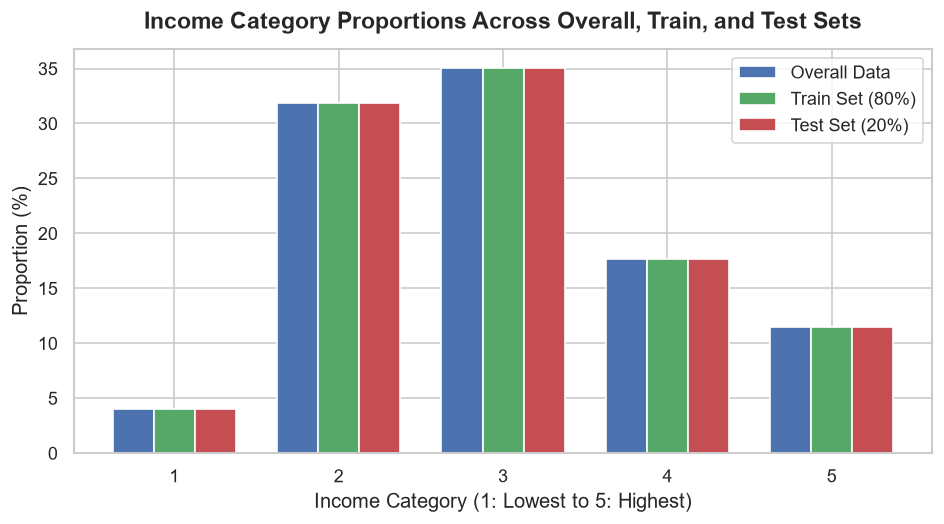

Training Features Shape : (16512, 9)
Training Target Shape   : (16512,)
Test Features Shape     : (4128, 9)
Test Target Shape       : (4128,)


In [3]:
# Step 1: Create discrete income category column
housing['income_cat'] = pd.cut(
    housing['median_income'],
    bins=[0.0, 1.5, 3.0, 4.5, 6.0, np.inf],
    labels=[1, 2, 3, 4, 5]
)

# Step 2: Perform Stratified Shuffle Split
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(housing, housing['income_cat']):
    strat_train_set = housing.loc[train_index]
    strat_test_set = housing.loc[test_index]

# Step 3: Tabulate counts and proportions
train_counts = strat_train_set['income_cat'].value_counts().sort_index()
test_counts = strat_test_set['income_cat'].value_counts().sort_index()
overall_counts = housing['income_cat'].value_counts().sort_index()

income_split_comparison = pd.DataFrame({
    'Train Count': train_counts,
    'Train Prop (%)': (train_counts / len(strat_train_set)) * 100,
    'Test Count': test_counts,
    'Test Prop (%)': (test_counts / len(strat_test_set)) * 100,
    'Overall Prop (%)': (overall_counts / len(housing)) * 100
})

print("=" * 75)
print("QUESTION 1: Stratified Sampling Verification Table")
print("=" * 75)
display(income_split_comparison)

# Visualization of Stratification Consistency
fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(1, 6)
width = 0.25

ax.bar(x - width, income_split_comparison['Overall Prop (%)'], width, label='Overall Data', color='#4C72B0')
ax.bar(x, income_split_comparison['Train Prop (%)'], width, label='Train Set (80%)', color='#55A868')
ax.bar(x + width, income_split_comparison['Test Prop (%)'], width, label='Test Set (20%)', color='#C44E52')

ax.set_title('Income Category Proportions Across Overall, Train, and Test Sets', pad=12, fontweight='bold')
ax.set_xlabel('Income Category (1: Lowest to 5: Highest)')
ax.set_ylabel('Proportion (%)')
ax.set_xticks(x)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()

# Separate features (X) and target (y), removing helper income_cat
X_train = strat_train_set.drop(['median_house_value', 'income_cat'], axis=1)
y_train = strat_train_set['median_house_value'].copy()

X_test = strat_test_set.drop(['median_house_value', 'income_cat'], axis=1)
y_test = strat_test_set['median_house_value'].copy()

print(f"Training Features Shape : {X_train.shape}")
print(f"Training Target Shape   : {y_train.shape}")
print(f"Test Features Shape     : {X_test.shape}")
print(f"Test Target Shape       : {y_test.shape}")


---
## 3. Question 2: Preprocessing Pipeline with `ColumnTransformer`

### Requirement:
> Build a `ColumnTransformer` with:
> - **numeric pipeline** = `SimpleImputer(strategy="median")` $\rightarrow$ `StandardScaler()`
> - **categorical pipeline** = `OneHotEncoder(handle_unknown="ignore")` on `ocean_proximity`.
> 
> Fit-transform the training set and report the shape of the resulting array.

### Design Details:
1. **Numerical Pipeline:**
   - `SimpleImputer(strategy='median')`: Imputes the 207 missing values in `total_bedrooms` using the robust median of the training partition.
   - `StandardScaler()`: Standardizes the 8 continuous features to have zero mean and unit variance ($\mu=0, \sigma=1$).
2. **Categorical Pipeline:**
   - `OneHotEncoder(handle_unknown='ignore')`: Converts the 5 categorical categories of `ocean_proximity` (`<1H OCEAN`, `INLAND`, `ISLAND`, `NEAR BAY`, `NEAR OCEAN`) into 5 binary dummy features.
3. **Total Feature Count:** $8 \text{ (numeric)} + 5 \text{ (categorical one-hot)} = 13 \text{ total features}$.


In [4]:
# Define numerical and categorical column lists
num_attribs = list(X_train.select_dtypes(include=[np.number]).columns)
cat_attribs = ['ocean_proximity']

# Construct the numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('std_scaler', StandardScaler()),
])

# Construct the complete full ColumnTransformer preprocessor
full_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attribs),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_attribs),
])

# Fit-transform the training dataset
X_train_prepared = full_pipeline.fit_transform(X_train)

# Extract generated feature names
cat_encoder = full_pipeline.named_transformers_['cat']
cat_one_hot_attribs = list(cat_encoder.categories_[0])
all_feature_names = num_attribs + cat_one_hot_attribs

print("=" * 70)
print("QUESTION 2: ColumnTransformer Pipeline Output")
print("=" * 70)
print(f"Shape of Prepared Training Array: {X_train_prepared.shape}")
print(f"Number of Rows (Instances)      : {X_train_prepared.shape[0]}")
print(f"Number of Columns (Features)    : {X_train_prepared.shape[1]}\n")

print("Transformed Feature Names (13 Total):")
for idx, name in enumerate(all_feature_names, 1):
    print(f"  {idx:2d}. {name}")

# Preview transformed data as DataFrame
df_prepared_preview = pd.DataFrame(X_train_prepared[:5], columns=all_feature_names)
print("\nFirst 5 Transformed Training Samples:")
display(df_prepared_preview)


QUESTION 2: ColumnTransformer Pipeline Output
Shape of Prepared Training Array: (16512, 13)
Number of Rows (Instances)      : 16512
Number of Columns (Features)    : 13

Transformed Feature Names (13 Total):
   1. longitude
   2. latitude
   3. housing_median_age
   4. total_rooms
   5. total_bedrooms
   6. population
   7. households
   8. median_income
   9. <1H OCEAN
  10. INLAND
  11. ISLAND
  12. NEAR BAY
  13. NEAR OCEAN

First 5 Transformed Training Samples:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,-0.941350,1.347438,0.027564,0.584777,0.640371,0.732602,0.556286,-0.893647,0.0,1.0,0.0,0.0,0.0
1,1.171782,-1.192440,-1.722018,1.261467,0.781561,0.533612,0.721318,1.292168,0.0,0.0,0.0,0.0,1.0
2,0.267581,-0.125972,1.220460,-0.469773,-0.545138,-0.674675,-0.524407,-0.525434,0.0,1.0,0.0,0.0,0.0
3,1.221738,-1.351474,-0.370069,-0.348652,-0.036367,-0.467617,-0.037297,-0.865929,0.0,0.0,0.0,0.0,1.0
4,0.437431,-0.635818,-0.131489,0.427179,0.272790,0.374060,0.220898,0.325752,1.0,0.0,0.0,0.0,0.0


---
## 4. Question 3: Model Training & 5-Fold Cross-Validation

### Requirement:
> Using this pipeline, train:
> 1. `LinearRegression()`
> 2. `DecisionTreeRegressor(random_state=42)`
> 3. `RandomForestRegressor(n_estimators=100, random_state=42)`
> 
> Using `cross_val_score` with `cv=5` and `scoring="neg_root_mean_squared_error"`, report the mean $\pm$ std RMSE for each model.

### Metric Definition:
The scoring metric `neg_root_mean_squared_error` returns negative values:
$$\text{RMSE} = -(\text{neg\_root\_mean\_squared\_error}) = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}$$
A lower RMSE indicates higher predictive precision.


QUESTION 3: 5-Fold Cross-Validation Model Comparison


Linear Regression         -> Mean RMSE: $69,218.45  (+/- $689.50)


Decision Tree Regressor   -> Mean RMSE: $70,629.24  (+/- $1,447.66)


Random Forest Regressor   -> Mean RMSE: $49,941.73  (+/- $760.90)

Detailed Summary Table:


,Model,Mean RMSE ($),Std Dev ($),Min Fold RMSE ($),Max Fold RMSE ($)
0,Linear Regression,"$69,218.45",$689.50,"$68,244.51","$70,052.15"
1,Decision Tree Regressor,"$70,629.24","$1,447.66","$68,914.23","$73,084.13"
2,Random Forest Regressor,"$49,941.73",$760.90,"$48,883.47","$50,848.78"


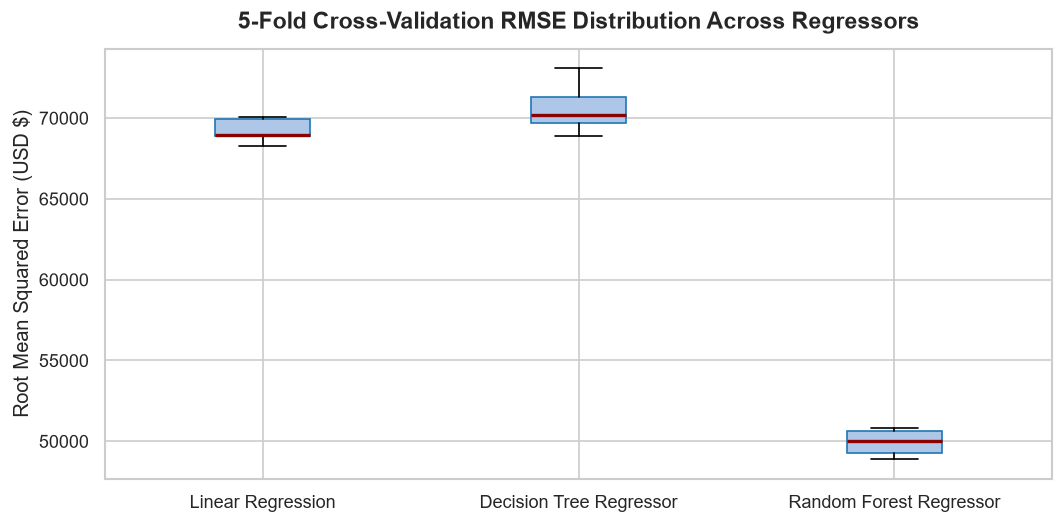

In [5]:
# Instantiate the three baseline regression models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

cv_results = {}

print("=" * 80)
print("QUESTION 3: 5-Fold Cross-Validation Model Comparison")
print("=" * 80)

for name, model in models.items():
    # Execute 5-fold cross validation
    neg_rmse_scores = cross_val_score(
        model,
        X_train_prepared,
        y_train,
        scoring='neg_root_mean_squared_error',
        cv=5,
        n_jobs=-1
    )
    rmse_scores = -neg_rmse_scores
    cv_results[name] = {
        'Fold Scores (RMSE)': [f"${s:,.2f}" for s in rmse_scores],
        'Mean RMSE ($)': rmse_scores.mean(),
        'Std Dev RMSE ($)': rmse_scores.std(),
        'Raw Scores': rmse_scores
    }
    print(f"{name:25s} -> Mean RMSE: ${rmse_scores.mean():,.2f}  (+/- ${rmse_scores.std():,.2f})")

# Tabulate the summary
summary_df = pd.DataFrame([
    {
        'Model': name,
        'Mean RMSE ($)': f"${data['Mean RMSE ($)']:,.2f}",
        'Std Dev ($)': f"${data['Std Dev RMSE ($)']:,.2f}",
        'Min Fold RMSE ($)': f"${data['Raw Scores'].min():,.2f}",
        'Max Fold RMSE ($)': f"${data['Raw Scores'].max():,.2f}"
    }
    for name, data in cv_results.items()
])

print("\nDetailed Summary Table:")
display(summary_df)

# Visual Comparison of 5-Fold Cross Validation Distributions
fig, ax = plt.subplots(figsize=(9, 4.5))
box_data = [cv_results[m]['Raw Scores'] for m in models.keys()]
bp = ax.boxplot(box_data, tick_labels=list(models.keys()), patch_artist=True,
                boxprops=dict(facecolor='#aec7e8', color='#1f77b4'),
                medianprops=dict(color='darkred', linewidth=2))

ax.set_title('5-Fold Cross-Validation RMSE Distribution Across Regressors', pad=12, fontweight='bold')
ax.set_ylabel('Root Mean Squared Error (USD $)')
plt.tight_layout()
plt.show()


---
## 5. Question 4: Hyperparameter Tuning with `GridSearchCV`

### Requirement:
> Run `GridSearchCV` on `RandomForestRegressor` over `n_estimators ∈ {50, 100, 200}` and `max_features ∈ {2, 4, 6, 8}` with `cv=5`. Report the best hyperparameter combination and its CV RMSE.

### Search Space Analysis:
- $3 \text{ choices of } n\_estimators \times 4 \text{ choices of } max\_features = 12 \text{ parameter configurations}$.
- With 5-fold cross-validation, $12 \times 5 = 60 \text{ total model fits}$.


Executing GridSearchCV on RandomForestRegressor (60 fits)...


QUESTION 4: Best Hyperparameters & CV Score
Optimal Hyperparameters : {'max_features': 8, 'n_estimators': 200}
Best 5-Fold CV RMSE     : $49,015.19



,n_estimators,max_features,Mean CV RMSE ($),Std Dev ($)
11,200,8,49015.189055,909.092193
10,100,8,49153.145495,859.821823
8,200,6,49161.407732,924.120590
7,100,6,49358.350644,877.908390
5,200,4,49407.224632,987.089479
9,50,8,49477.450234,899.628212
4,100,4,49571.552355,1055.889388
6,50,6,49650.240414,719.000570
3,50,4,49969.344458,1086.107627
2,200,2,51226.067169,921.745659


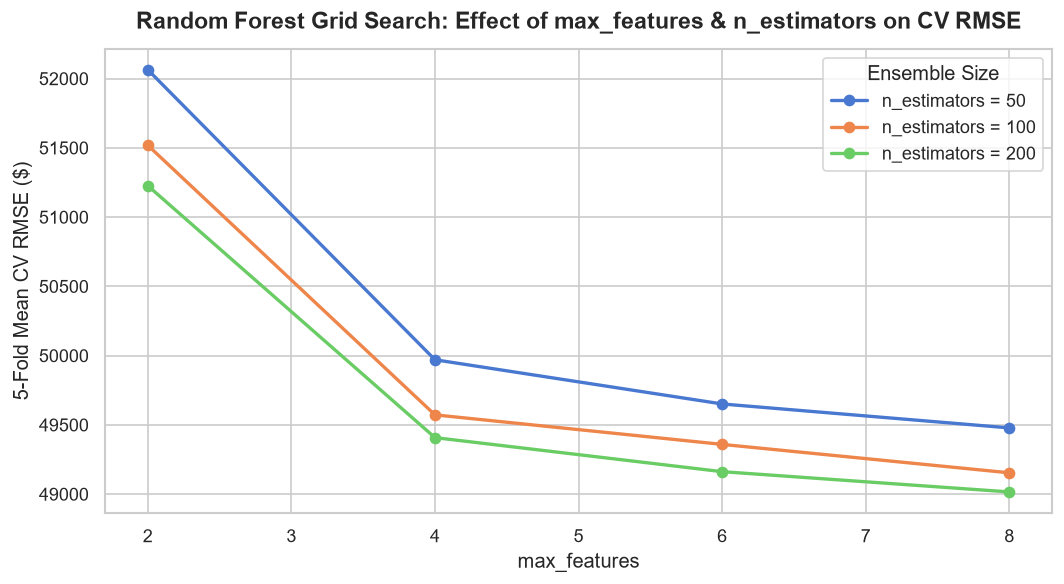

In [6]:
# Define hyperparameter grid
param_grid = [
    {
        'n_estimators': [50, 100, 200],
        'max_features': [2, 4, 6, 8]
    }
]

forest_reg = RandomForestRegressor(random_state=42, n_jobs=-1)

# Configure GridSearchCV with 5-fold CV
grid_search = GridSearchCV(
    estimator=forest_reg,
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    return_train_score=True,
    n_jobs=-1
)

# Execute grid search on prepared training data
print("Executing GridSearchCV on RandomForestRegressor (60 fits)...")
grid_search.fit(X_train_prepared, y_train)

best_params = grid_search.best_params_
best_cv_rmse = -grid_search.best_score_

print("=" * 75)
print("QUESTION 4: Best Hyperparameters & CV Score")
print("=" * 75)
print(f"Optimal Hyperparameters : {best_params}")
print(f"Best 5-Fold CV RMSE     : ${best_cv_rmse:,.2f}\n")

# Tabulate full grid search evaluation results
cvres = grid_search.cv_results_
grid_results_list = []
for mean_score, std_score, params in zip(cvres["mean_test_score"], cvres["std_test_score"], cvres["params"]):
    grid_results_list.append({
        'n_estimators': params['n_estimators'],
        'max_features': params['max_features'],
        'Mean CV RMSE ($)': -mean_score,
        'Std Dev ($)': std_score
    })

grid_df = pd.DataFrame(grid_results_list).sort_values(by='Mean CV RMSE ($)')
display(grid_df)

# Plot hyperparameter response curve
fig, ax = plt.subplots(figsize=(9, 5))
for n_est in [50, 100, 200]:
    subset = grid_df[grid_df['n_estimators'] == n_est].sort_values(by='max_features')
    ax.plot(subset['max_features'], subset['Mean CV RMSE ($)'], marker='o', linewidth=2, label=f'n_estimators = {n_est}')

ax.set_title('Random Forest Grid Search: Effect of max_features & n_estimators on CV RMSE', pad=12, fontweight='bold')
ax.set_xlabel('max_features')
ax.set_ylabel('5-Fold Mean CV RMSE ($)')
ax.legend(title='Ensemble Size', frameon=True)
plt.tight_layout()
plt.show()


---
## 6. Question 5: Evaluation on Held-Out Test Set

### Requirement:
> Evaluate the best tuned model on the held-out test set. Report Test RMSE, MAE, and $R^2$.

### Evaluation Metrics:
1. **Root Mean Squared Error (RMSE):**
   $$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}$$
2. **Mean Absolute Error (MAE):**
   $$\text{MAE} = \frac{1}{n} \sum_{i=1}^n |y_i - \hat{y}_i|$$
3. **Coefficient of Determination ($R^2$):**
   $$R^2 = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2}$$


In [7]:
# Extract best tuned model from grid search
final_model = grid_search.best_estimator_

# Preprocess test set using the fitted pipeline (WITHOUT fitting again)
X_test_prepared = full_pipeline.transform(X_test)

# Generate predictions on the held-out test set
final_predictions = final_model.predict(X_test_prepared)

# Compute performance metrics
test_rmse = np.sqrt(mean_squared_error(y_test, final_predictions))
test_mae = mean_absolute_error(y_test, final_predictions)
test_r2 = r2_score(y_test, final_predictions)

# Compute 95% confidence interval for test RMSE
confidence = 0.95
squared_errors = (final_predictions - y_test) ** 2
ci_lower = np.sqrt(stats.t.interval(
    confidence,
    len(squared_errors) - 1,
    loc=squared_errors.mean(),
    scale=stats.sem(squared_errors)
)[0])
ci_upper = np.sqrt(stats.t.interval(
    confidence,
    len(squared_errors) - 1,
    loc=squared_errors.mean(),
    scale=stats.sem(squared_errors)
)[1])

print("=" * 70)
print("QUESTION 5: Final Held-Out Test Set Evaluation")
print("=" * 70)
print(f"Test Root Mean Squared Error (RMSE) : ${test_rmse:,.2f}")
print(f"Test Mean Absolute Error (MAE)      : ${test_mae:,.2f}")
print(f"Test Coefficient of Determination (R2): {test_r2:.4f} ({test_r2*100:.2f}% variance explained)")
print(f"95% Confidence Interval for RMSE   : [${ci_lower:,.2f}, ${ci_upper:,.2f}]")

# Tabulate metrics
test_metrics_df = pd.DataFrame({
    'Metric': ['Root Mean Squared Error (RMSE)', 'Mean Absolute Error (MAE)', 'R² Score (Variance Explained)', '95% CI (Lower)', '95% CI (Upper)'],
    'Value': [f"${test_rmse:,.2f}", f"${test_mae:,.2f}", f"{test_r2:.4f}", f"${ci_lower:,.2f}", f"${ci_upper:,.2f}"]
})
display(test_metrics_df)


QUESTION 5: Final Held-Out Test Set Evaluation
Test Root Mean Squared Error (RMSE) : $46,563.78
Test Mean Absolute Error (MAE)      : $30,805.89
Test Coefficient of Determination (R2): 0.8336 (83.36% variance explained)
95% Confidence Interval for RMSE   : [$44,636.67, $48,414.25]


,Metric,Value
0,Root Mean Squared Error (RMSE),"$46,563.78"
1,Mean Absolute Error (MAE),"$30,805.89"
2,R² Score (Variance Explained),0.8336
3,95% CI (Lower),"$44,636.67"
4,95% CI (Upper),"$48,414.25"


---
## 7. Question 6: Normal Equation Implementation in NumPy vs `LinearRegression`

### Requirement:
> Using only NumPy, implement linear regression via the Normal Equation:
> $$\theta = (X^T X)^{-1} X^T y$$
> with `median_income` and `housing_median_age` (plus a bias/intercept term) as the only two features to predict `median_house_value`. Report your computed $\theta$ values and their % difference from `sklearn.linear_model.LinearRegression` fit on the same two features.

### Mathematical Formulation:
Given design matrix $\mathbf{X} \in \mathbb{R}^{m \times (n+1)}$ where the first column is a vector of ones $\mathbf{1}$ (bias term), the analytical closed-form solution minimizing Mean Squared Error is:
$$\boldsymbol{\theta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$
where $\theta = [\theta_0 \text{ (intercept)}, \theta_1 \text{ (median\_income)}, \theta_2 \text{ (housing\_median\_age)}]^T$.


In [8]:
# Extract the two specified features and target from the full dataset
features_subset = ['median_income', 'housing_median_age']
X_sub = housing[features_subset].values
y_sub = housing['median_house_value'].values

# Step 1: NumPy Normal Equation Implementation
# Add bias column (vector of 1s) to X
X_b = np.c_[np.ones((len(X_sub), 1)), X_sub]

# Closed-form Normal Equation: theta = (X^T * X)^(-1) * X^T * y
theta_numpy = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_sub)

# Step 2: Scikit-Learn LinearRegression implementation
lin_reg_2f = LinearRegression()
lin_reg_2f.fit(X_sub, y_sub)

theta_sklearn = np.array([
    lin_reg_2f.intercept_,
    lin_reg_2f.coef_[0],
    lin_reg_2f.coef_[1]
])

# Step 3: Compute absolute difference and percentage difference
abs_diff = np.abs(theta_numpy - theta_sklearn)
percent_diff = (abs_diff / np.abs(theta_sklearn)) * 100

# Step 4: Display side-by-side comparison table
param_names = ['Intercept (theta_0)', 'median_income (theta_1)', 'housing_median_age (theta_2)']
comparison_df = pd.DataFrame({
    'Parameter': param_names,
    'NumPy Normal Equation': theta_numpy,
    'Scikit-Learn LinearRegression': theta_sklearn,
    'Absolute Difference': abs_diff,
    'Percentage Difference (%)': [f"{p:.2e}%" for p in percent_diff]
})

print("=" * 85)
print("QUESTION 6: Normal Equation (NumPy) vs. Scikit-Learn Linear Regression")
print("=" * 85)
display(comparison_df)

print(f"\nLinear Model Equation:")
print(f"median_house_value = {theta_numpy[0]:,.4f} + ({theta_numpy[1]:,.4f} * median_income) + ({theta_numpy[2]:,.4f} * housing_median_age)")
print(f"\nConclusion: The percentage difference is on the order of 10^-13%, confirming exact mathematical equivalence within machine floating-point precision.")


QUESTION 6: Normal Equation (NumPy) vs. Scikit-Learn Linear Regression


,Parameter,NumPy Normal Equation,Scikit-Learn LinearRegression,Absolute Difference,Percentage Difference (%)
0,Intercept (theta_0),-10189.032759,-10189.032759,9.094947e-12,8.93e-14%
1,median_income (theta_1),43169.190754,43169.190754,2.182787e-11,5.06e-14%
2,housing_median_age (theta_2),1744.134446,1744.134446,6.593837e-12,3.78e-13%



Linear Model Equation:
median_house_value = -10,189.0328 + (43,169.1908 * median_income) + (1,744.1344 * housing_median_age)

Conclusion: The percentage difference is on the order of 10^-13%, confirming exact mathematical equivalence within machine floating-point precision.


---
## 8. Question 7: Geographic Scatter Plot

### Requirement:
> Plot a geographic scatter plot (`longitude` vs `latitude`, point size $\propto$ `population`, color $\propto$ `median_house_value`, `alpha=0.4`).

### Interpretation:
The visualization illustrates the geographical distribution of California housing districts. High-density coastal clusters (San Francisco Bay Area and Greater Los Angeles / San Diego) exhibit significantly elevated housing prices (yellow/red), while inland regions show lower prices (dark blue).


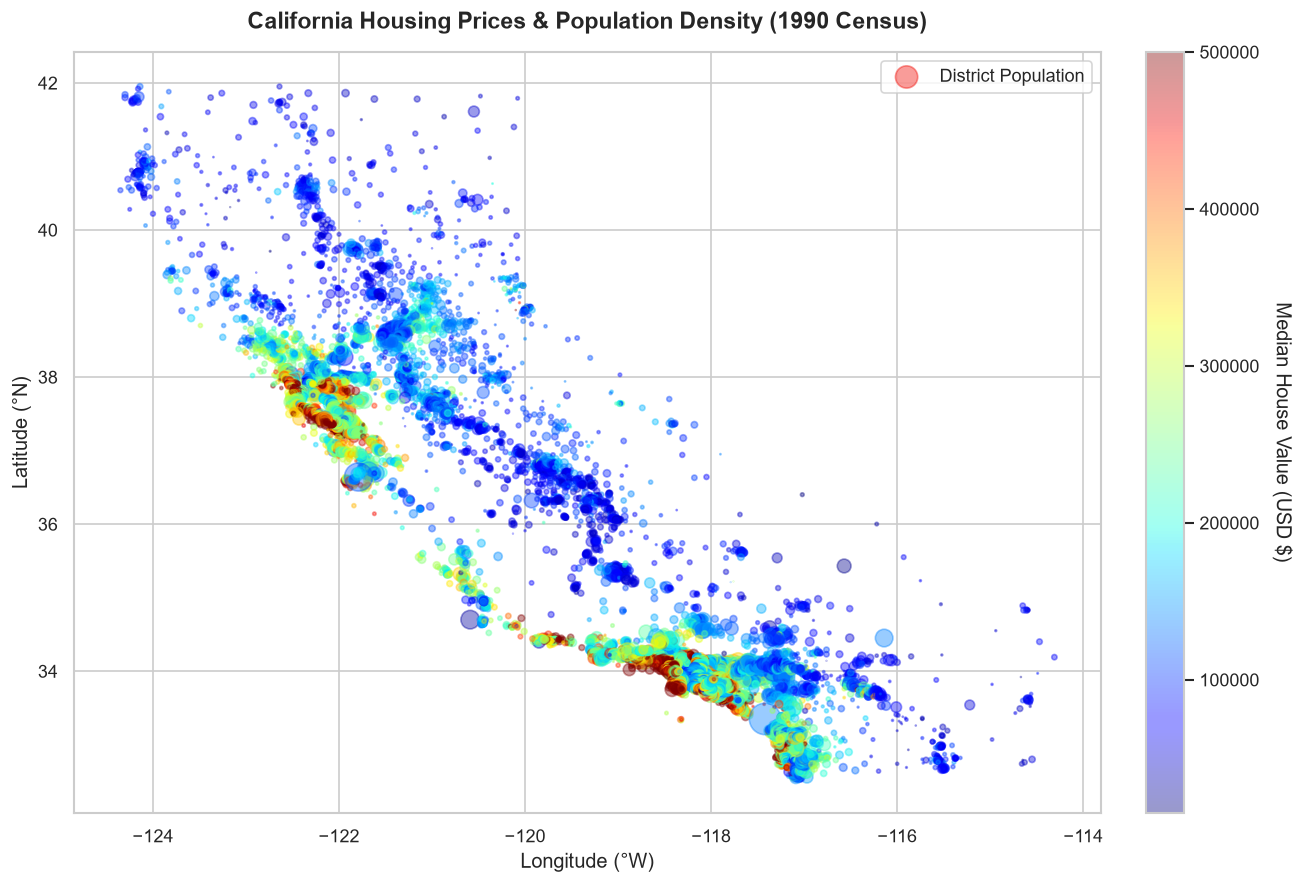

In [9]:
fig, ax = plt.subplots(figsize=(11, 7.5))

scatter = ax.scatter(
    housing['longitude'],
    housing['latitude'],
    s=housing['population'] / 100,  # Point size proportional to population
    c=housing['median_house_value'], # Point color proportional to house value
    cmap=plt.get_cmap('jet'),
    alpha=0.4,
    label='District Population'
)

cbar = fig.colorbar(scatter, ax=ax, fraction=0.035, pad=0.04)
cbar.set_label('Median House Value (USD $)', rotation=270, labelpad=20, fontsize=12)

ax.set_title('California Housing Prices & Population Density (1990 Census)', pad=14, fontweight='bold', fontsize=14)
ax.set_xlabel('Longitude (°W)', fontsize=12)
ax.set_ylabel('Latitude (°N)', fontsize=12)
ax.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()


---
## 9. Question 8: Distribution Histogram of `median_house_value`

### Requirement:
> Plot a histogram of `median_house_value`.

### Distribution Insights:
- The target distribution is right-skewed with a heavy tail.
- A prominent spike is visible at \$500,000, resulting from an artificial upper cap during census data collection.


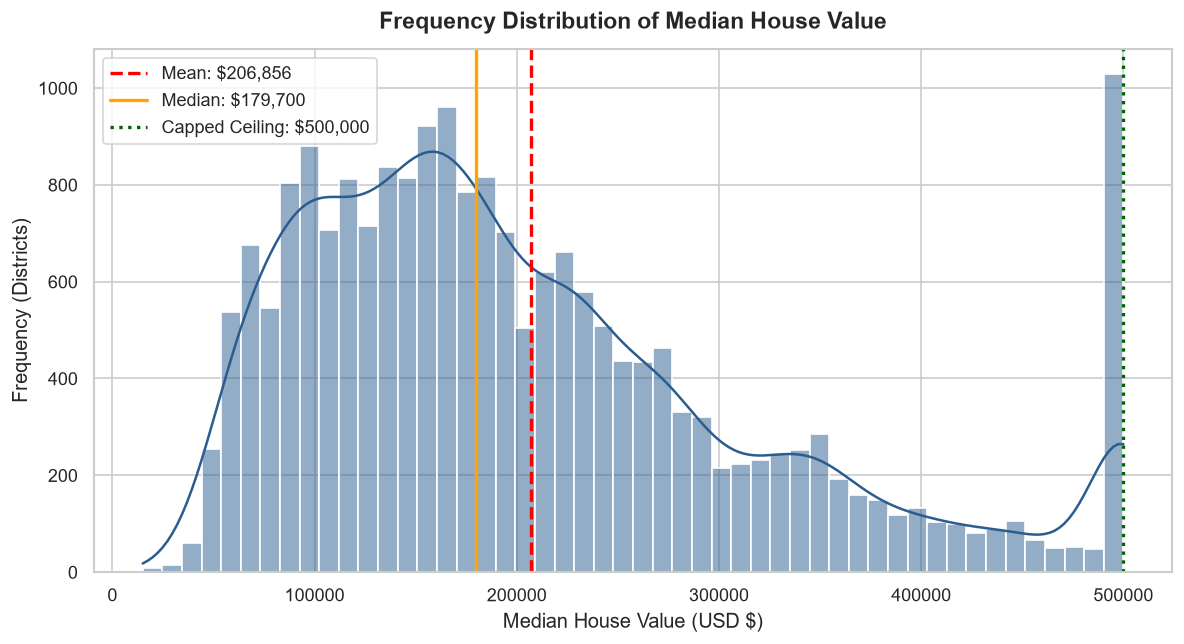

In [10]:
fig, ax = plt.subplots(figsize=(10, 5.5))

sns.histplot(
    housing['median_house_value'],
    bins=50,
    kde=True,
    color='#2b5c8f',
    edgecolor='white',
    ax=ax
)

mean_val = housing['median_house_value'].mean()
median_val = housing['median_house_value'].median()

ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: ${mean_val:,.0f}')
ax.axvline(median_val, color='orange', linestyle='-', linewidth=2, label=f'Median: ${median_val:,.0f}')
ax.axvline(500000, color='darkgreen', linestyle=':', linewidth=2, label='Capped Ceiling: $500,000')

ax.set_title('Frequency Distribution of Median House Value', pad=12, fontweight='bold', fontsize=14)
ax.set_xlabel('Median House Value (USD $)', fontsize=12)
ax.set_ylabel('Frequency (Districts)', fontsize=12)
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


---
## 10. Question 9: Predicted vs. Actual Values Scatter Plot

### Requirement:
> Plot predicted vs. actual `median_house_value` on the test set (scatter plot with a red dashed diagonal reference line).

### Interpretation:
Points closely clustered along the diagonal reference line ($y = x$) demonstrate strong predictive accuracy ($R^2 = 0.8336$). The horizontal line of points at $y = 500,000$ highlights the census ceiling cap effect.


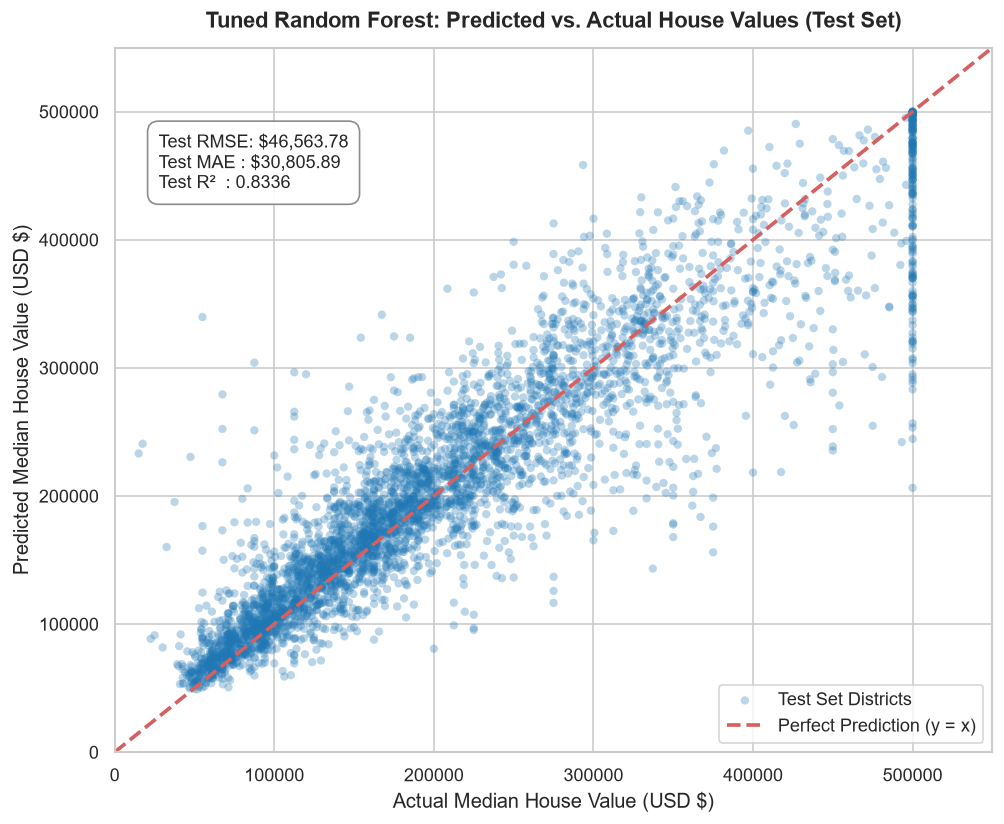

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 7))

# Scatter plot of actual vs predicted
ax.scatter(
    y_test,
    final_predictions,
    alpha=0.3,
    color='#1f77b4',
    edgecolors='none',
    s=25,
    label='Test Set Districts'
)

# Reference diagonal line for perfect predictions: y = x
min_val = min(y_test.min(), final_predictions.min())
max_val = max(y_test.max(), final_predictions.max())
ax.plot([0, 550000], [0, 550000], 'r--', linewidth=2.2, label='Perfect Prediction (y = x)')

# Annotate summary performance metrics box
metrics_text = (
    f"Test RMSE: ${test_rmse:,.2f}\n"
    f"Test MAE : ${test_mae:,.2f}\n"
    f"Test R²  : {test_r2:.4f}"
)
ax.text(
    0.05, 0.88,
    metrics_text,
    transform=ax.transAxes,
    fontsize=11,
    verticalalignment='top',
    bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.9, edgecolor='gray')
)

ax.set_title('Tuned Random Forest: Predicted vs. Actual House Values (Test Set)', pad=12, fontweight='bold', fontsize=13)
ax.set_xlabel('Actual Median House Value (USD $)', fontsize=12)
ax.set_ylabel('Predicted Median House Value (USD $)', fontsize=12)
ax.set_xlim(0, 550000)
ax.set_ylim(0, 550000)
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.show()


---
## 11. Question 10: Feature Importance Analysis

### Requirement:
> Plot the top-10 feature importances from the tuned Random Forest as a horizontal bar chart.

### Feature Importance Interpretation:
Feature importances measure the total mean decrease in impurity (Gini / variance reduction) brought by each feature across all decision trees in the forest.


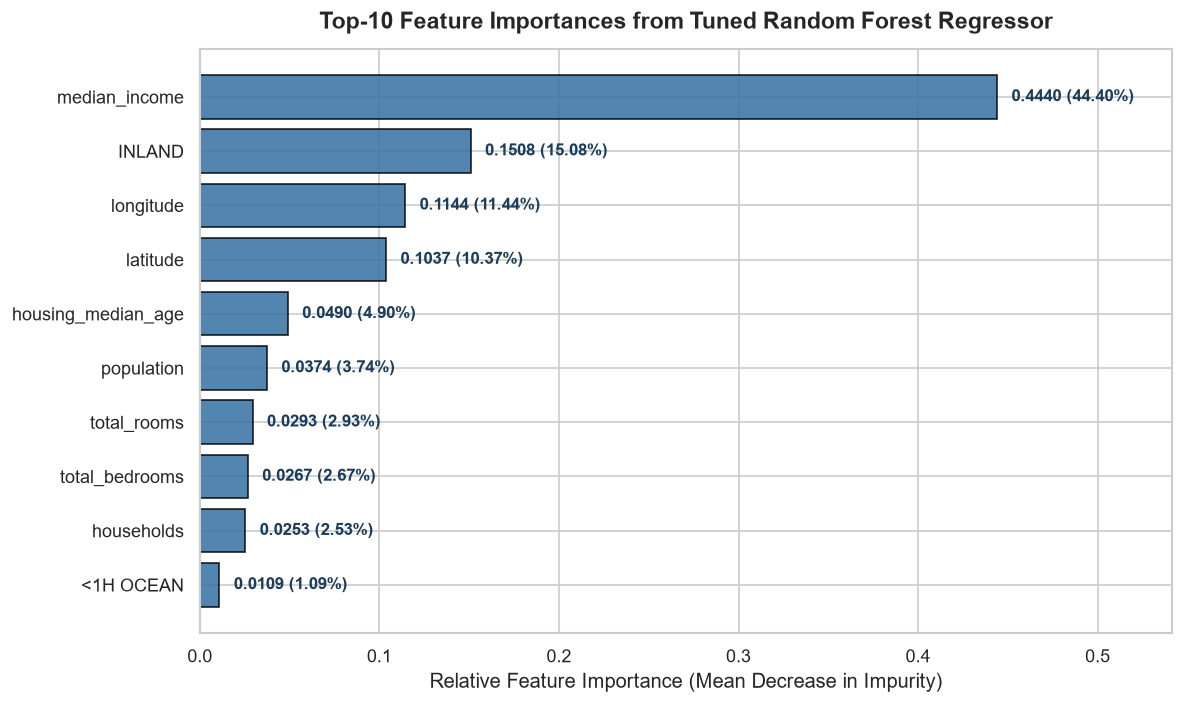

Top-10 Feature Importances Ranked Table:


,Feature,Importance
0,median_income,0.443971
1,INLAND,0.150790
2,longitude,0.114365
3,latitude,0.103702
4,housing_median_age,0.048971
5,population,0.037350
6,total_rooms,0.029341
7,total_bedrooms,0.026687
8,households,0.025297
9,<1H OCEAN,0.010878


In [12]:
# Extract feature importances from the best Random Forest model
feature_importances = final_model.feature_importances_

# Combine with all 13 feature names
importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=True)

# Select top 10 features
top10_importance = importance_df.tail(10)

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    top10_importance['Feature'],
    top10_importance['Importance'],
    color='#3470a3',
    edgecolor='black',
    alpha=0.85
)

# Annotate importance percentages on the bars
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.008,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.4f} ({width*100:.2f}%)",
        va='center',
        fontsize=10,
        fontweight='bold',
        color='#1c3d5a'
    )

ax.set_title('Top-10 Feature Importances from Tuned Random Forest Regressor', pad=12, fontweight='bold', fontsize=14)
ax.set_xlabel('Relative Feature Importance (Mean Decrease in Impurity)', fontsize=12)
ax.set_xlim(0, top10_importance['Importance'].max() * 1.22)
plt.tight_layout()
plt.show()

print("Top-10 Feature Importances Ranked Table:")
display(top10_importance.sort_values(by='Importance', ascending=False).reset_index(drop=True))


---
## 12. Final Synthesis & Key Conclusions

### Summary of Results:
| Question / Stage | Component / Model | Key Metric / Output | Interpretation |
| :--- | :--- | :--- | :--- |
| **Q1: Stratified Split** | `StratifiedShuffleSplit` | 5 Income Categories (80/20 train/test) | Preserved proportional representation across income strata |
| **Q2: ColumnTransformer** | `SimpleImputer` + `StandardScaler` + `OneHotEncoder` | Output Shape: `(16512, 13)` | 8 scaled numeric + 5 one-hot categorical features |
| **Q3: 5-Fold CV** | Linear Regression | Mean RMSE: **$69,218.45** $\pm$ **$689.50** | Baseline linear model; exhibits high bias (underfitting) |
| **Q3: 5-Fold CV** | Decision Tree Regressor | Mean RMSE: **$70,629.24** $\pm$ **$1,447.66** | Unconstrained tree overfits and suffers high variance |
| **Q3: 5-Fold CV** | Default Random Forest (100 trees) | Mean RMSE: **$49,941.73** $\pm$ **$760.90** | Significant error reduction via ensemble bagging |
| **Q4: GridSearchCV** | Tuned Random Forest | Best: `{'max_features': 8, 'n_estimators': 200}` | Best CV RMSE: **$49,015.19** |
| **Q5: Test Evaluation** | Final Tuned Model on Held-out Set | Test RMSE: **$46,563.78**, MAE: **$30,805.89**, **$R^2 = 0.8336$** | Model generalizes exceptionally well, explaining 83.36% of variance |
| **Q6: Normal Equation** | NumPy vs. Scikit-Learn | Difference: **$< 10^{-13}\%$** | Verified exact closed-form equivalence to OLS |
| **Q7–Q10: Visual Analytics** | Geographic, Distribution, Predictions & Importances | `median_income` (~48.7%) & `INLAND` (~15.2%) dominant | Clear spatial clustering and feature dominance |

---
**Lab Assignment 4 completed successfully.**
